# Lección 4 — Redes de Neuronas




<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:6px;color:inherit">

### Cómo usar este notebook

Este notebook está pensado para estudiar el Tema 4 de forma práctica:

- primero se entiende la red como **función matemática**;
- después se estudian sus **componentes**: capas lineales, activaciones, pesos y sesgos;
- luego se hacen cálculos de **número de parámetros** y **forward pass**;
- finalmente se introduce **backpropagation** con derivadas y código.

El enfoque está orientado a examen: se insiste en dimensiones, fórmulas, interpretación y ejercicios tipo test.

</div>

## Índice

1. [Idea general de una red neuronal](#1.-Idea-general-de-una-red-neuronal)
2. [Red neuronal con una entrada y una salida](#2.-Red-neuronal-con-una-entrada-y-una-salida)
3. [Activaciones y funciones lineales a trozos](#3.-Activaciones-y-funciones-lineales-a-trozos)
4. [Notación matricial general](#4.-Notación-matricial-general)
5. [Número de parámetros](#5.-Número-de-parámetros)
6. [Por qué la activación debe ser no lineal](#6.-Por-qué-la-activación-debe-ser-no-lineal)
7. [Redes neuronales como aprendizaje de características](#7.-Redes-neuronales-como-aprendizaje-de-características)
8. [Forward pass desde cero con NumPy](#8.-Forward-pass-desde-cero-con-NumPy)
9. [Backpropagation en redes neuronales](#9.-Backpropagation-en-redes-neuronales)
10. [Gradientes de una red pequeña](#10.-Gradientes-de-una-red-pequeña)
11. [Activación saturada del ejercicio](#11.-Activación-saturada-del-ejercicio)
12. [Ejercicios tipo examen resueltos](#12.-Ejercicios-tipo-examen-resueltos)
13. [Resumen final](#13.-Resumen-final)

## 1. Idea general de una red neuronal

Una red neuronal es un modelo matemático que aproxima una función:

$$
\hat{y} = f(x; \Phi)
$$

Donde:

- $x$ es la entrada.
- $\hat{y}$ es la predicción.
- $\Phi$ representa todos los parámetros de la red: pesos y sesgos.
- $f$ es la función implementada por la red.

En una red **feedforward**, la información fluye hacia delante:

$$
\text{entrada} \rightarrow \text{capas ocultas} \rightarrow \text{salida}
$$

<div style="background:rgba(112,173,71,0.14);border-left:5px solid #70ad47;padding:14px;border-radius:6px;color:inherit">

### Idea clave

Una red neuronal no es más que una composición de funciones. Cada capa transforma la entrada anterior y pasa el resultado a la siguiente capa.

</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

## 2. Red neuronal con una entrada y una salida

Una red con una entrada, una capa oculta y una salida puede escribirse como:

$$
\hat{y} = \phi_0 + \sum_{j=1}^{D} \phi_j h_j
$$

donde cada unidad oculta es:

$$
h_j = a(\theta_{j0} + \theta_{j1}x)
$$

Por tanto:

$$
\hat{y} = \phi_0 + \sum_{j=1}^{D} \phi_j a(\theta_{j0} + \theta_{j1}x)
$$

Si usamos ReLU como activación:

$$
a(z) = \max(0,z)
$$

cada unidad oculta introduce un posible **punto de articulación** en la función.

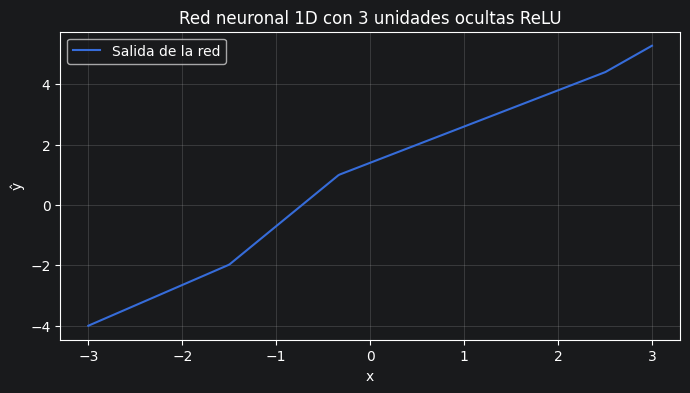

In [2]:
def relu(z):
    return np.maximum(0, z)

x = np.linspace(-3, 3, 400)

# Red 1D sencilla: y = phi0 + sum phi_j ReLU(theta_j0 + theta_j1 x)
theta0 = np.array([1.5, -0.5, -2.0])
theta1 = np.array([1.0, -1.5, 0.8])
phi = np.array([1.2, -0.9, 0.7])
phi0 = -0.4

hidden = relu(theta0[:, None] + theta1[:, None] * x[None, :])
y_hat = phi0 + phi @ hidden

plt.figure(figsize=(8, 4))
plt.plot(x, y_hat, label="Salida de la red")
plt.xlabel("x")
plt.ylabel("ŷ")
plt.title("Red neuronal 1D con 3 unidades ocultas ReLU")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="background:rgba(255,192,0,0.16);border-left:5px solid #bf9000;padding:14px;border-radius:6px;color:inherit">

### Interpretación para examen

Una red con ReLU genera funciones **lineales a trozos**. Cada unidad oculta puede crear un cambio de pendiente. Al aumentar el número de unidades ocultas, aumenta la capacidad de la red para aproximar funciones más complejas.

</div>

## 3. Activaciones y funciones lineales a trozos

Las funciones de activación introducen no linealidad. Algunas activaciones habituales son:

| Activación | Fórmula | Uso típico |
|---|---:|---|
| Lineal | $a(z)=z$ | Salida en regresión |
| Sigmoide | $\sigma(z)=\frac{1}{1+e^{-z}}$ | Salida en clasificación binaria |
| Tanh | $\tanh(z)$ | Valores en $[-1,1]$ |
| ReLU | $\max(0,z)$ | Capas ocultas |
| Leaky ReLU | $\max(\alpha z,z)$ | Variante de ReLU |

En redes profundas modernas, ReLU y sus variantes son muy usadas porque son simples y ayudan a reducir ciertos problemas de saturación.

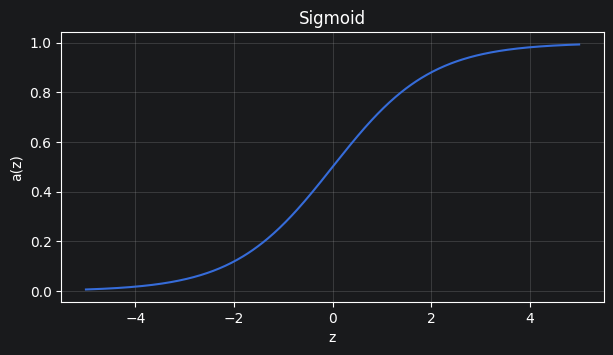

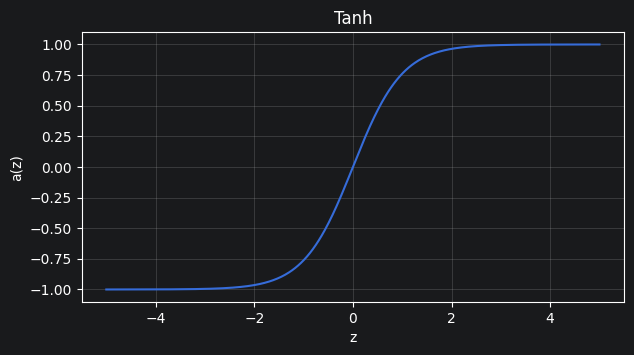

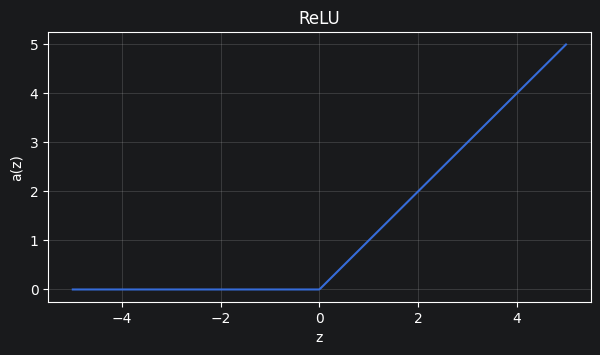

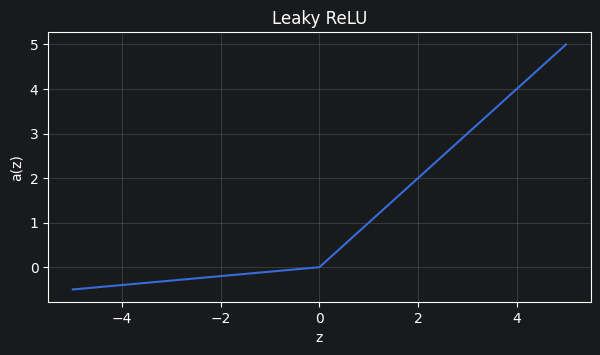

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def leaky_relu(z, alpha=0.1):
    return np.where(z >= 0, z, alpha * z)

z = np.linspace(-5, 5, 500)
activations = {
    "Sigmoid": sigmoid(z),
    "Tanh": tanh(z),
    "ReLU": relu(z),
    "Leaky ReLU": leaky_relu(z),
}

for name, values in activations.items():
    plt.figure(figsize=(7, 3.5))
    plt.plot(z, values)
    plt.xlabel("z")
    plt.ylabel("a(z)")
    plt.title(name)
    plt.grid(True, alpha=0.3)
    plt.show()

## 4. Notación matricial general

Para una red con:

- $D_i$ entradas,
- $D$ unidades ocultas,
- $D_o$ salidas,

la red con una capa oculta se puede escribir como:

$$
z = \Omega_0 x + \beta_0
$$

$$
h = a(z)
$$

$$
\hat{y} = \Omega_1 h + \beta_1
$$

Donde las dimensiones son:

| Elemento | Dimensión |
|---|---:|
| $x$ | $D_i \times 1$ |
| $\Omega_0$ | $D \times D_i$ |
| $\beta_0$ | $D \times 1$ |
| $z$ | $D \times 1$ |
| $h$ | $D \times 1$ |
| $\Omega_1$ | $D_o \times D$ |
| $\beta_1$ | $D_o \times 1$ |
| $\hat{y}$ | $D_o \times 1$ |

<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:6px;color:inherit">

### Regla práctica

En una capa lineal, la matriz de pesos tiene dimensión:

$$
\text{n.º neuronas destino} \times \text{n.º neuronas origen}
$$

Los sesgos tienen dimensión:

$$
\text{n.º neuronas destino} \times 1
$$

</div>

In [4]:
Di = 3   # entradas
D = 4    # ocultas
Do = 2   # salidas

x_sample = rng.normal(size=(Di, 1))
Omega0 = rng.normal(size=(D, Di))
beta0 = rng.normal(size=(D, 1))
Omega1 = rng.normal(size=(Do, D))
beta1 = rng.normal(size=(Do, 1))

z = Omega0 @ x_sample + beta0
h = relu(z)
y_hat = Omega1 @ h + beta1

print("x shape      :", x_sample.shape)
print("Omega0 shape :", Omega0.shape)
print("beta0 shape  :", beta0.shape)
print("z shape      :", z.shape)
print("h shape      :", h.shape)
print("Omega1 shape :", Omega1.shape)
print("beta1 shape  :", beta1.shape)
print("y_hat shape  :", y_hat.shape)

x shape      : (3, 1)
Omega0 shape : (4, 3)
beta0 shape  : (4, 1)
z shape      : (4, 1)
h shape      : (4, 1)
Omega1 shape : (2, 4)
beta1 shape  : (2, 1)
y_hat shape  : (2, 1)


## 5. Número de parámetros

Para una red completamente conectada con una capa oculta:

$$
D_i \rightarrow D \rightarrow D_o
$$

el número total de parámetros es:

$$
\underbrace{D \cdot D_i}_{\Omega_0} + \underbrace{D}_{\beta_0} + \underbrace{D_o \cdot D}_{\Omega_1} + \underbrace{D_o}_{\beta_1}
$$

Agrupando:

$$
N_{params} = (D_i + 1)D + (D + 1)D_o
$$

<div style="background:rgba(112,173,71,0.14);border-left:5px solid #70ad47;padding:14px;border-radius:6px;color:inherit">

### Muy importante

La capa de entrada no tiene parámetros. Los parámetros están en las conexiones hacia la capa oculta y hacia la capa de salida, incluyendo los sesgos.

</div>

In [5]:
def count_params_one_hidden(Di, D, Do):
    """Número de parámetros de una red Di -> D -> Do completamente conectada."""
    return (Di + 1) * D + (D + 1) * Do

examples = [
    (5, 2, 4),
    (4, 5, 3),
    (3, 10, 5),
    (5, 31, 21),
]

for Di, D, Do in examples:
    print(f"{Di} -> {D} -> {Do}: {count_params_one_hidden(Di, D, Do)} parámetros")

5 -> 2 -> 4: 24 parámetros
4 -> 5 -> 3: 43 parámetros
3 -> 10 -> 5: 95 parámetros
5 -> 31 -> 21: 858 parámetros


## 6. Por qué la activación debe ser no lineal

Supongamos una red de una capa oculta:

$$
\hat{y} = \Omega_1 a(\Omega_0x + \beta_0) + \beta_1
$$

Si la activación fuese lineal, por ejemplo:

$$
a(z)=\Omega_a z
$$

entonces:

$$
\hat{y} = \Omega_1 \Omega_a (\Omega_0x + \beta_0) + \beta_1
$$

$$
\hat{y} = \underbrace{\Omega_1\Omega_a\Omega_0}_{\Omega'}x + \underbrace{\Omega_1\Omega_a\beta_0 + \beta_1}_{\beta'}
$$

Eso vuelve a ser un modelo lineal:

$$
\hat{y}=\Omega'x+\beta'
$$

<div style="background:rgba(192,0,0,0.12);border-left:5px solid #c00000;padding:14px;border-radius:6px;color:inherit">

### Conclusión

Sin activaciones no lineales, apilar muchas capas lineales no aumenta la capacidad expresiva: todo se puede reducir a una única capa lineal.

</div>

In [6]:
# Demostración numérica: composición de capas lineales = otra capa lineal
x = rng.normal(size=(3, 1))
A = rng.normal(size=(5, 3))
b = rng.normal(size=(5, 1))
C = rng.normal(size=(2, 5))
d = rng.normal(size=(2, 1))

# Dos capas lineales
out_two_layers = C @ (A @ x + b) + d

# Capa lineal equivalente
A_equiv = C @ A
b_equiv = C @ b + d
out_equiv = A_equiv @ x + b_equiv

print("Salida con dos capas lineales:")
print(out_two_layers)
print("\nSalida con capa equivalente:")
print(out_equiv)
print("\nDiferencia máxima:", np.max(np.abs(out_two_layers - out_equiv)))

Salida con dos capas lineales:
[[ 2.6989]
 [-1.2937]]

Salida con capa equivalente:
[[ 2.6989]
 [-1.2937]]

Diferencia máxima: 4.440892098500626e-16


## 7. Redes neuronales como aprendizaje de características

Un modelo lineal con sigmoide separa los datos mediante una frontera lineal:

$$
\hat{y}=\sigma(\phi_1x_1 + \phi_2x_2 + \phi_0)
$$

Pero muchos problemas no son linealmente separables. Una solución clásica sería crear características manuales:

$$
(x_1, x_2) \rightarrow (x_1, x_2, x_1^2, x_2^2, x_1x_2)
$$

Una red neuronal intenta aprender automáticamente transformaciones útiles en sus capas ocultas:

$$
h = a(\Omega_0x + \beta_0)
$$

Después, la salida usa esas características aprendidas:

$$
\hat{y}=\Omega_1h+\beta_1
$$

In [7]:
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_moons(n_samples=600, noise=0.25, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

linear_clf = LogisticRegression(random_state=RANDOM_STATE)
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation="relu",
    max_iter=2000,
    random_state=RANDOM_STATE,
)

linear_clf.fit(X_train, y_train)
mlp_clf.fit(X_train, y_train)

pred_linear = linear_clf.predict(X_test)
pred_mlp = mlp_clf.predict(X_test)

print("Accuracy modelo lineal:", accuracy_score(y_test, pred_linear))
print("Accuracy MLP          :", accuracy_score(y_test, pred_mlp))

Accuracy modelo lineal: 0.8444444444444444
Accuracy MLP          : 0.9111111111111111


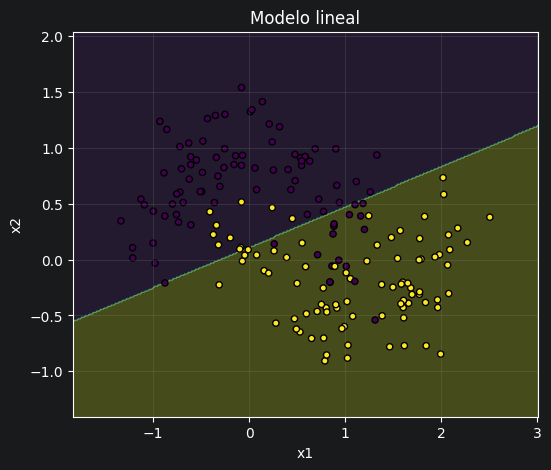

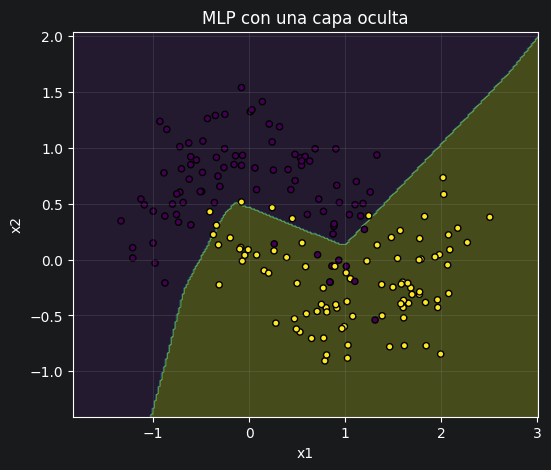

In [8]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=20)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True, alpha=0.2)
    plt.show()

plot_decision_boundary(linear_clf, X_test, y_test, "Modelo lineal")
plot_decision_boundary(mlp_clf, X_test, y_test, "MLP con una capa oculta")

<div style="background:rgba(255,192,0,0.16);border-left:5px solid #bf9000;padding:14px;border-radius:6px;color:inherit">

### Interpretación

El modelo lineal solo puede construir una frontera recta. El MLP transforma internamente las entradas y puede construir fronteras no lineales más adaptadas al problema.

</div>

## 8. Forward pass desde cero con NumPy

Vamos a implementar el paso hacia delante de una red:

$$
x \rightarrow z_1 \rightarrow h_1 \rightarrow z_2 \rightarrow \hat{y}
$$

Con:

$$
z_1 = W_1x+b_1
$$

$$
h_1=\text{ReLU}(z_1)
$$

$$
z_2=W_2h_1+b_2
$$

Para clasificación multiclase, se suele aplicar softmax:

$$
\text{softmax}(z_i)=\frac{e^{z_i}}{\sum_j e^{z_j}}
$$

In [9]:
def softmax(logits):
    logits = logits - np.max(logits, axis=0, keepdims=True)  # estabilidad numérica
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=0, keepdims=True)

def forward_mlp(x, W1, b1, W2, b2):
    z1 = W1 @ x + b1
    h1 = relu(z1)
    z2 = W2 @ h1 + b2
    probs = softmax(z2)
    cache = {"x": x, "z1": z1, "h1": h1, "z2": z2, "probs": probs}
    return probs, cache

Di, D, Do = 3, 4, 2
x = rng.normal(size=(Di, 1))
W1 = rng.normal(size=(D, Di))
b1 = rng.normal(size=(D, 1))
W2 = rng.normal(size=(Do, D))
b2 = rng.normal(size=(Do, 1))

probs, cache = forward_mlp(x, W1, b1, W2, b2)

print("Probabilidades de clase:")
print(probs)
print("\nSuma de probabilidades:", probs.sum())
print("Clase predicha:", np.argmax(probs))

Probabilidades de clase:
[[0.57]
 [0.43]]

Suma de probabilidades: 1.0
Clase predicha: 0


## 9. Backpropagation en redes neuronales

El objetivo de backpropagation no es solo obtener derivadas respecto a la entrada, sino sobre todo calcular derivadas respecto a los **parámetros**:

$$
\frac{\partial J}{\partial W_1}, \quad
\frac{\partial J}{\partial b_1}, \quad
\frac{\partial J}{\partial W_2}, \quad
\frac{\partial J}{\partial b_2}
$$

Para una red:

$$
z_1=W_1x+b_1
$$

$$
h_1=a(z_1)
$$

$$
z_2=W_2h_1+b_2
$$

$$
s=\text{softmax}(z_2)
$$

$$
J=-\log(s_y)
$$

con softmax + cross-entropy, se obtiene una simplificación muy importante:

$$
\frac{\partial J}{\partial z_2} = s - y_{onehot}
$$

A partir de ahí se propaga hacia atrás.

## 10. Gradientes de una red pequeña

Para una sola muestra:

$$
dz_2 = s - y_{onehot}
$$

$$
\frac{\partial J}{\partial W_2} = dz_2 h_1^T
$$

$$
\frac{\partial J}{\partial b_2} = dz_2
$$

$$
dh_1 = W_2^T dz_2
$$

$$
dz_1 = dh_1 \odot \mathbb{1}(z_1 > 0)
$$

$$
\frac{\partial J}{\partial W_1} = dz_1 x^T
$$

$$
\frac{\partial J}{\partial b_1} = dz_1
$$

In [10]:
def cross_entropy_from_probs(probs, target_class):
    eps = 1e-12
    return -np.log(probs[target_class, 0] + eps)

def backward_mlp(cache, W2, target_class):
    x = cache["x"]
    z1 = cache["z1"]
    h1 = cache["h1"]
    probs = cache["probs"]

    y_onehot = np.zeros_like(probs)
    y_onehot[target_class, 0] = 1

    dz2 = probs - y_onehot
    dW2 = dz2 @ h1.T
    db2 = dz2

    dh1 = W2.T @ dz2
    dz1 = dh1 * (z1 > 0)
    dW1 = dz1 @ x.T
    db1 = dz1

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads

target_class = 1
loss = cross_entropy_from_probs(probs, target_class)
grads = backward_mlp(cache, W2, target_class)

print("Loss:", loss)
for name, grad in grads.items():
    print(f"{name} shape: {grad.shape}")
    print(grad, "\n")

Loss: 0.8439192030356397
dW1 shape: (4, 3)
[[-0.1598 -0.1783  0.0784]
 [ 0.      0.      0.    ]
 [ 0.      0.      0.    ]
 [ 0.      0.      0.    ]] 

db1 shape: (4, 1)
[[-0.2247]
 [-0.    ]
 [ 0.    ]
 [-0.    ]] 

dW2 shape: (2, 4)
[[ 0.0622  0.      0.      0.    ]
 [-0.0622  0.      0.      0.    ]] 

db2 shape: (2, 1)
[[ 0.57]
 [-0.57]] 



### Comprobación numérica del gradiente

Una forma de verificar backpropagation es comparar un gradiente analítico con una aproximación numérica:

$$
\frac{\partial J}{\partial \theta} \approx \frac{J(\theta+h)-J(\theta-h)}{2h}
$$

Esta técnica no se usa para entrenar redes grandes porque sería demasiado costosa, pero es muy útil para comprobar derivadas.

In [11]:
def loss_with_params(W1, b1, W2, b2, x, target_class):
    probs, _ = forward_mlp(x, W1, b1, W2, b2)
    return cross_entropy_from_probs(probs, target_class)

h = 1e-5
row, col = 0, 0

W1_plus = W1.copy()
W1_minus = W1.copy()
W1_plus[row, col] += h
W1_minus[row, col] -= h

loss_plus = loss_with_params(W1_plus, b1, W2, b2, x, target_class)
loss_minus = loss_with_params(W1_minus, b1, W2, b2, x, target_class)
num_grad = (loss_plus - loss_minus) / (2 * h)
ana_grad = grads["dW1"][row, col]

print("Gradiente numérico :", num_grad)
print("Gradiente analítico:", ana_grad)
print("Diferencia absoluta:", abs(num_grad - ana_grad))

Gradiente numérico : -0.15981518998176014
Gradiente analítico: -0.15981518998528238
Diferencia absoluta: 3.5222380567745404e-12


## 11. Activación saturada del ejercicio

En la hoja de ejercicios aparece la activación:

$$
a(z)=\max(-1, \min(1,z))
$$

Esta función recorta el valor de $z$ al intervalo $[-1,1]$:

$$
a(z)=
\begin{cases}
-1, & z < -1 \\
z, & -1 \le z \le 1 \\
1, & z > 1
\end{cases}
$$

Su derivada es:

$$
a'(z)=
\begin{cases}
0, & z < -1 \\
1, & -1 < z < 1 \\
0, & z > 1
\end{cases}
$$

En $z=-1$ y $z=1$ la derivada no está definida de forma clásica porque hay un cambio brusco de pendiente. En implementación se suele tomar un subgradiente o definir un valor convencional.

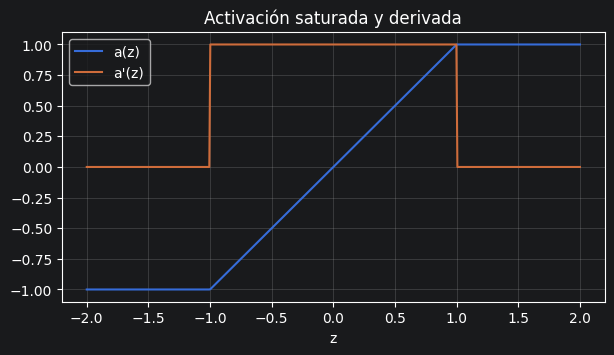

In [12]:
def clipped_activation(z):
    return np.maximum(-1, np.minimum(1, z))

def clipped_activation_derivative(z):
    return np.where((z > -1) & (z < 1), 1.0, 0.0)

z = np.linspace(-2, 2, 500)

plt.figure(figsize=(7, 3.5))
plt.plot(z, clipped_activation(z), label="a(z)")
plt.plot(z, clipped_activation_derivative(z), label="a'(z)")
plt.xlabel("z")
plt.title("Activación saturada y derivada")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Derivada de $a(Mx+b)$ respecto a $x$

Sea:

$$
z = Mx+b
$$

con:

$$
x \in \mathbb{R}^3, \quad M \in \mathbb{R}^{2\times 3}, \quad b \in \mathbb{R}^2
$$

La activación se aplica componente a componente:

$$
a(z)=
\begin{bmatrix}
a(z_1) \\
a(z_2)
\end{bmatrix}
$$

Por regla de la cadena:

$$
\frac{\partial a(Mx+b)}{\partial x}
= \frac{\partial z}{\partial x}^T \frac{\partial a}{\partial z}
$$

Según la convención de jacobiano que usemos, lo más habitual en ML es escribir:

$$
J_{a,x} = \frac{\partial a}{\partial z} M
$$

donde:

$$
\frac{\partial a}{\partial z} =
\begin{bmatrix}
a'(z_1) & 0 \\
0 & a'(z_2)
\end{bmatrix}
$$

Por tanto:

$$
J_{a,x} =
\begin{bmatrix}
a'(z_1) & 0 \\
0 & a'(z_2)
\end{bmatrix}M
$$

El resultado tiene dimensión $2\times 3$.

In [13]:
M = np.array([
    [1.0, -2.0, 0.5],
    [0.3,  1.0, -1.5],
])
b = np.array([[0.2], [-0.4]])
x = np.array([[0.5], [1.0], [-0.2]])

z = M @ x + b
D_activation = np.diagflat(clipped_activation_derivative(z))
J_ax = D_activation @ M

print("z =")
print(z)
print("\na(z) =")
print(clipped_activation(z))
print("\nDa(z) =")
print(D_activation)
print("\nJacobian d a(Mx+b) / dx =")
print(J_ax)
print("\nShape:", J_ax.shape)

z =
[[-1.4 ]
 [ 1.05]]

a(z) =
[[-1.]
 [ 1.]]

Da(z) =
[[0. 0.]
 [0. 0.]]

Jacobian d a(Mx+b) / dx =
[[0. 0. 0.]
 [0. 0. 0.]]

Shape: (2, 3)


## 12. Ejercicios tipo examen resueltos

### Ejercicio 1

Dada una red con 5 neuronas en la entrada, 2 en la capa oculta y 4 en la salida, calcular el número de parámetros.

Aplicamos:

$$
N_{params} = (D_i+1)D + (D+1)D_o
$$

Sustituyendo:

$$
N_{params}=(5+1)\cdot2+(2+1)\cdot4=12+12=24
$$

**Respuesta correcta:** 24.

### Ejercicio 2

Red con 4 entradas, 5 neuronas ocultas y 3 salidas.

$$
N_{params}=(4+1)\cdot5+(5+1)\cdot3=25+18=43
$$

**Respuesta correcta:** 43.

### Ejercicio 3

Red con 3 entradas, 10 neuronas ocultas y 5 salidas.

$$
N_{params}=(3+1)\cdot10+(10+1)\cdot5=40+55=95
$$

**Respuesta correcta:** 95.

### Ejercicio 4

Red con 5 entradas, 31 neuronas ocultas y 21 salidas.

$$
N_{params}=(5+1)\cdot31+(31+1)\cdot21
$$

$$
N_{params}=186+672=858
$$

**Respuesta correcta:** 858.

### Ejercicio 5

Se quiere construir un clasificador biclase con una única salida y usar **Binary Cross Entropy**.

La salida debe representar una probabilidad:

$$
\hat{y}\in[0,1]
$$

Por tanto, la activación adecuada es:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

**Respuesta correcta:** Sigmoide.

<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:6px;color:inherit">

### Regla de examen

- Clasificación binaria con 1 salida: **sigmoide + binary cross-entropy**.
- Clasificación multiclase con varias salidas: **softmax + categorical cross-entropy**.
- Regresión: salida lineal + MSE/MAE/Huber.

</div>

### Ejercicio 6

Dada:

$$
a(z)=\max(-1,\min(1,z))
$$

se pide:

1. Dibujar la gráfica y calcular la derivada.
2. Calcular $\frac{\partial a(Mx+b)}{\partial x}$.

La solución queda:

$$
a(z)=
\begin{cases}
-1, & z < -1 \\
z, & -1 \le z \le 1 \\
1, & z > 1
\end{cases}
$$

$$
a'(z)=
\begin{cases}
0, & z < -1 \\
1, & -1 < z < 1 \\
0, & z > 1
\end{cases}
$$

Y si $z=Mx+b$:

$$
\frac{\partial a(Mx+b)}{\partial x}
=
\begin{bmatrix}
a'(z_1) & 0 \\
0 & a'(z_2)
\end{bmatrix}M
$$

con $z_1$ y $z_2$ las dos componentes de $Mx+b$.

## 13. Resumen final

| Concepto | Idea clave |
|---|---|
| Red neuronal | Composición de capas lineales y activaciones no lineales |
| Capa lineal | $z=Wx+b$ |
| Activación | Introduce no linealidad |
| ReLU | $\max(0,z)$, genera funciones lineales a trozos |
| Capa oculta | Aprende características intermedias |
| Parámetros | Pesos + sesgos |
| Una capa oculta | $N_{params}=(D_i+1)D+(D+1)D_o$ |
| Activación lineal | Hace que toda la red sea equivalente a un modelo lineal |
| Backpropagation | Calcula gradientes usando la regla de la cadena |
| BCE binaria | Requiere salida sigmoide si usamos una única neurona de salida |
| Softmax + CE | Caso típico de clasificación multiclase |

<div style="background:rgba(112,173,71,0.14);border-left:5px solid #70ad47;padding:14px;border-radius:6px;color:inherit">

### Lo mínimo que hay que dominar para examen

1. Saber contar parámetros de una red totalmente conectada.
2. Saber escribir el forward pass en forma matricial.
3. Entender por qué las activaciones deben ser no lineales.
4. Identificar activación de salida según el tipo de problema.
5. Aplicar la regla de la cadena en una red pequeña.
6. Calcular derivadas de activaciones definidas a trozos.

</div>

## 14. Mini-cheatsheet de código

```python
# Red Di -> D -> Do
z1 = W1 @ x + b1
h1 = relu(z1)
z2 = W2 @ h1 + b2
probs = softmax(z2)

# Parámetros
n_params = (Di + 1) * D + (D + 1) * Do

# Softmax + cross-entropy
dz2 = probs - y_onehot

# Backprop
dW2 = dz2 @ h1.T
db2 = dz2
dh1 = W2.T @ dz2
dz1 = dh1 * (z1 > 0)
dW1 = dz1 @ x.T
db1 = dz1
```